In [1]:
!pip install ipython-autotime

In [2]:
%load_ext autotime

time: 284 µs (started: 2021-08-16 00:36:18 -07:00)


## 4.3 Imports<a id='4.3_Imports'></a>

In [3]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import __version__ as sklearn_version
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression
import datetime

time: 752 ms (started: 2021-08-16 00:36:18 -07:00)


In [4]:
#return the first 5 and last 5 rows of this dataframe
def p(df_):
    if df_.shape[0] > 6:
        print(df_.shape)
        return pd.concat([df_.head(), df_.tail()])
    else:
        return df_

def rcp(file_, pd_=None, ic_=None):
    if (pd_ == None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_))
    elif (pd_ != None) and (ic_ == None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_)
    elif (pd_ != None) and (ic_ != None):
        return pd.read_csv(os.path.join('..', 'processed_data', file_), parse_dates=pd_, index_col = ic_)
    else:
        return pd.read_csv(os.path.join('..', 'processed_data', file_), index_col = ic_)
    
def rcr(file_, pd_=None):
    if pd_ == None:
        return pd.read_csv(os.path.join('..', 'raw_data', file_))
    else:
        return pd.read_csv(os.path.join('..', 'raw_data', file_), parse_dates=pd_)
    
#sort dataframe by column
def s(df_, column_):
    return df_.sort_values(column_)

#reset index and sort dataframe by column
def sr(df_, column_, ascending_=True):
    df_ = df_.sort_values(column_, ascending=ascending_)
    return df_.reset_index(drop=True)

#print length of list
def pl(list_):
    print(len(list_))
    return list_

#print length of dictionary
def pdc(dict_):
    print(len(dict_))
    return dict_

time: 606 µs (started: 2021-08-16 00:36:18 -07:00)


## 4.4 Load Data<a id='4.4_Load_Data'></a>

In [5]:
df_train = rcp('161_train_split.csv', None, 0)
p(df_train)

(7186, 853)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626,11
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517,-10
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941,22
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,10
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672,4
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443,-5
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158,14
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266,-8
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158,-4
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941,-8


time: 1.34 s (started: 2021-08-16 00:36:18 -07:00)


In [6]:
df_test = rcp('161_test_split.csv', None, 0)
p(df_test)

(3080, 853)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff,spread_a
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,7
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833,15
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195,-1
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443,-5
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266,-10
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266,2
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266,24
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158,6
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724,10
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049,5


time: 594 ms (started: 2021-08-16 00:36:20 -07:00)


In [7]:
X_train = df_train.drop(columns = 'spread_a')
p(X_train)

(7186, 852)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.130110,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,-0.585219,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.134827,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.043060,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-1.305366,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.289072,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-0.982624,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,0.474528,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158
9937,1.000585,-0.900053,0.904205,0.538977,-0.538977,0.900053,-0.904205,-0.059179,-1.185216,-0.131998,...,-0.744181,-0.842308,-1.476897,1.504101,-1.134447,-0.267004,0.514600,-1.005843,-0.237558,1.478941


time: 23.5 ms (started: 2021-08-16 00:36:20 -07:00)


In [8]:
y_train = df_train.spread_a
p(y_train)

(7186,)


3134     11
8383    -10
7423     22
2528     10
10064     4
3378     -5
1965     14
1161     -8
2771     -4
9937     -8
Name: spread_a, dtype: int64

time: 1.87 ms (started: 2021-08-16 00:36:20 -07:00)


In [9]:
X_test = df_test.drop(columns = 'spread_a')
p(X_test)

(3080, 852)


,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.538992,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.156038,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,2.117137,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.606997,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.209591,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.262579,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,2.355580,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724
5706,-0.999416,0.242833,-0.146573,-0.192442,0.192442,-0.242833,0.146573,-0.114564,0.353411,0.091763,...,-0.267295,-0.461318,1.757094,-1.061144,0.054369,-3.438895,-1.134873,1.712504,-1.144157,0.989049


time: 18 ms (started: 2021-08-16 00:36:20 -07:00)


In [10]:
y_test = df_test.spread_a
p(y_test)

(3080,)


2583     7
9370    15
5655    -1
7258    -5
2386   -10
8109     2
9743    24
4546     6
4962    10
5706     5
Name: spread_a, dtype: int64

time: 1.95 ms (started: 2021-08-16 00:36:20 -07:00)


## 4.8 Initial Models<a id='4.8_Initial_Models'></a>

### 4.8.1 Imputing missing feature (predictor) values<a id='4.8.1_Imputing_missing_feature_(predictor)_values'></a>

Recall when performing EDA, you imputed (filled in) some missing values in pandas. You did this judiciously for exploratory/visualization purposes. You left many missing values in the data. You can impute missing values using scikit-learn, but note that you should learn values to impute from a train split and apply that to the test split to then assess how well your imputation worked.

#### 4.8.1.1 Impute missing values with median<a id='4.8.1.1_Impute_missing_values_with_median'></a>

There's missing values. Recall from your data exploration that many distributions were skewed. Your first thought might be to impute missing values using the median.

In [11]:
X_tr_scaled = X_train
X_tr_scaled

,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
3134,-0.999416,1.099997,-1.006300,-0.869106,0.869106,-1.099997,1.006300,-0.446871,-1.416010,-0.196035,...,0.130110,0.681655,-1.529913,0.347225,1.073355,1.120699,0.670210,-0.018242,0.800259,-0.480626
8383,-0.999416,-1.376256,1.381831,1.147929,-1.147929,1.376256,-1.381831,-1.074563,1.622779,0.541892,...,-0.585219,0.822020,0.882326,-0.004867,-0.341903,-0.861733,-2.815468,-0.223585,-0.786289,-0.970517
7423,-0.999416,-0.614332,0.617629,0.321641,-0.321641,0.614332,-0.617629,2.156205,-0.839025,-0.291209,...,-0.134827,-0.641787,-1.132292,-1.614433,-0.398513,-1.297868,0.016646,-0.037798,-0.714716,1.478941
2528,-0.999416,0.147592,-0.242098,-0.605934,0.605934,-0.147592,0.242098,0.125436,-0.031245,-0.757113,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
10064,-0.999416,1.385719,-1.388401,-0.777675,0.777675,-1.385719,1.388401,2.137743,-0.781326,-0.260570,...,0.043060,0.398060,-0.321900,-1.528206,-1.805683,0.520305,-0.774746,-0.624492,1.636988,-0.270672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3378,1.000585,1.004757,-0.910774,-0.595496,0.595496,-1.004757,0.910774,0.993128,-0.858258,-0.209483,...,-1.305366,-0.289963,-1.556421,0.280465,1.363611,-1.369957,-0.997370,0.808996,1.480208,0.855443
1965,1.000585,-0.614332,0.426579,0.488491,-0.488491,0.614332,-0.426579,0.402359,0.468809,-0.000505,...,0.289072,0.461081,-1.344357,-1.010846,0.733693,-2.209787,0.514600,-0.546266,-1.012939,0.499158
1161,-0.999416,0.528554,-0.528673,-0.300758,0.300758,-0.528554,0.528673,-0.188410,-0.569765,-0.042986,...,-0.982624,-1.403768,0.511212,-0.457557,-0.624954,-0.980679,-0.325698,-0.282254,0.287315,0.009266
2771,-0.999416,0.433314,-0.528673,-0.729611,0.729611,-0.433314,0.528673,0.771590,-0.165875,-0.721090,...,0.474528,1.062646,0.378671,-1.362938,0.507252,2.072266,0.234500,-1.103625,0.740614,0.499158


time: 15.2 ms (started: 2021-08-16 00:36:20 -07:00)


In [12]:
X_te_scaled = X_test
X_te_scaled

,away_home_a,losses_diff,wins_diff,win_pct_diff,opp_win_pct_diff,opp_losses_diff,opp_wins_diff,opp_opps_losses_diff,opp_opps_wins_diff,opp_opps_win_pct_diff,...,dreb_cma_sm_cmax12_diff,reb_cma_sm_cmax12_diff,ast_cma_sm_cmax12_diff,stl_cma_sm_cmax12_diff,blk_cma_sm_cmax12_diff,tov_cma_sm_cmax12_diff,pf_cma_sm_cmax12_diff,pts_cma_sm_cmax12_diff,spread_cma_sm_cmax12_diff,away_home_cma_sm_cmax12_diff
2583,1.000585,-0.328610,0.426579,1.350913,-1.350913,0.328610,-0.426579,0.070052,-0.031245,-0.273612,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
9370,-0.999416,1.385719,-1.388401,-1.970642,1.970642,-1.385719,1.388401,0.771590,-0.762094,-0.970663,...,-1.538992,-1.463925,-2.033568,-0.407258,-2.889366,-1.734003,-3.033323,-2.384573,1.170055,1.968833
5655,-0.999416,1.385719,-1.770502,-1.539212,1.539212,-1.385719,1.770502,1.362359,-0.127410,-0.408668,...,-1.156038,-1.075642,0.684720,1.197735,-0.722736,0.140296,0.141134,0.169322,1.661311,-1.193195
7258,1.000585,-2.614383,2.623659,1.681878,-1.681878,2.614383,-2.623659,-0.705333,-0.877491,-0.030213,...,2.117137,1.944940,-0.177999,-0.859949,0.944695,-1.957478,-1.539461,0.079540,-2.623345,0.855443
2386,1.000585,0.052352,-0.051047,-0.051521,0.051521,-0.052352,0.051047,0.014667,0.007220,-0.013957,...,-0.055345,-0.020170,-0.124983,-0.004867,0.054369,0.010537,0.078890,-0.037798,0.024878,0.009266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8109,-0.999416,0.528554,-0.624199,-0.788287,0.788287,-0.528554,0.624199,0.014667,0.314946,0.153835,...,0.606997,0.541290,0.670261,-0.105465,1.299796,1.120699,-0.263454,-0.164915,-0.523853,0.009266
9743,1.000585,-0.328610,0.331054,0.243728,-0.243728,0.328610,-0.331054,-1.499179,0.853465,0.406982,...,0.209591,0.260560,1.465504,-1.564134,0.563862,1.398239,-0.885896,1.174702,-1.358878,0.009266
4546,1.000585,1.004757,-0.910774,-0.694836,0.694836,-1.004757,0.910774,-0.188410,0.103385,0.029099,...,0.262579,0.681655,-0.310540,0.799916,-0.511734,0.407023,-0.450186,-0.380036,0.943406,0.499158
4962,-0.999416,0.623795,-0.624199,-0.319306,0.319306,-0.623795,0.624199,0.476205,-1.377545,-0.130825,...,2.355580,0.922281,2.101699,-1.463536,2.375392,0.327726,0.203378,1.252928,-2.181974,2.458724


time: 13.3 ms (started: 2021-08-16 00:36:20 -07:00)


##### 4.8.1.1.4 Train the model on the train split<a id='4.8.1.1.4_Train_the_model_on_the_train_split'></a>

In [13]:
lm = LinearRegression().fit(X_tr_scaled, y_train)

time: 452 ms (started: 2021-08-16 00:36:20 -07:00)


##### 4.8.1.1.5 Make predictions using the model on both train and test splits<a id='4.8.1.1.5_Make_predictions_using_the_model_on_both_train_and_test_splits'></a>

In [14]:
#Code task 11#
#Call the `predict()` method of the model (`lm`) on both the (scaled) train and test data
#Assign the predictions to `y_tr_pred` and `y_te_pred`, respectively
y_tr_pred = lm.predict(X_tr_scaled)
y_te_pred = lm.predict(X_te_scaled)

time: 15.2 ms (started: 2021-08-16 00:36:21 -07:00)


##### 4.8.1.1.6 Assess model performance<a id='4.8.1.1.6_Assess_model_performance'></a>

In [15]:
# r^2 - train, test
median_r2 = r2_score(y_train, y_tr_pred), r2_score(y_test, y_te_pred)
median_r2

(0.3063539710810024, 0.12919814951456787)

time: 2.75 ms (started: 2021-08-16 00:36:21 -07:00)


Recall that you estimated ticket price by simply using a known average. As expected, this produced an $R^2$ of zero for both the training and test set, because $R^2$ tells us how much of the variance you're explaining beyond that of using just the mean, and you were using just the mean. Here we see that our simple linear regression model explains over 80% of the variance on the train set and over 70% on the test set. Clearly you are onto something, although the much lower value for the test set suggests you're overfitting somewhat. This isn't a surprise as you've made no effort to select a parsimonious set of features or deal with multicollinearity in our data.

In [16]:
#Code task 12#
#Now calculate the mean absolute error scores using `sklearn`'s `mean_absolute_error` function
# as we did above for R^2
# MAE - train, test
median_mae = mean_absolute_error(y_train, y_tr_pred), mean_absolute_error(y_test, y_te_pred)
median_mae

(8.974112324259908, 10.000070630165448)

time: 2.01 ms (started: 2021-08-16 00:36:21 -07:00)


Using this model, then, on average you'd expect to estimate a ticket price within \\$9 or so of the real price. This is much, much better than the \\$19 from just guessing using the average. There may be something to this machine learning lark after all!

In [17]:
#Code task 13#
#And also do the same using `sklearn`'s `mean_squared_error`
# MSE - train, test
median_mse = mean_squared_error(y_train, y_tr_pred), mean_squared_error(y_test, y_te_pred)
median_mse

(129.78519211578478, 162.88820218110226)

time: 2.16 ms (started: 2021-08-16 00:36:21 -07:00)


#### 4.8.1.2 Impute missing values with the mean<a id='4.8.1.2_Impute_missing_values_with_the_mean'></a>

You chose to use the median for filling missing values because of the skew of many of our predictor feature distributions. What if you wanted to try something else, such as the mean?

##### 4.8.1.2.1 Learn the values to impute from the train set<a id='4.8.1.2.1_Learn_the_values_to_impute_from_the_train_set'></a>

In [18]:
#Code task 14#
#As we did for the median above, calculate mean values for imputing missing values
# These are the values we'll use to fill in any missing values
X_defaults_mean = X_train.mean()
X_defaults_mean

away_home_a                     0.003368
losses_diff                     0.007647
wins_diff                      -0.007791
win_pct_diff                   -0.003778
opp_win_pct_diff                0.003778
                                  ...   
tov_cma_sm_cmax12_diff         -0.006613
pf_cma_sm_cmax12_diff          -0.002371
pts_cma_sm_cmax12_diff          0.002319
spread_cma_sm_cmax12_diff      -0.001479
away_home_cma_sm_cmax12_diff    0.004551
Length: 852, dtype: float64

time: 10.7 ms (started: 2021-08-16 00:36:21 -07:00)


In [19]:
lm = LinearRegression().fit(X_tr_scaled, y_train)

time: 413 ms (started: 2021-08-16 00:36:21 -07:00)


##### 4.8.1.2.5 Make predictions using the model on both train and test splits<a id='4.8.1.2.5_Make_predictions_using_the_model_on_both_train_and_test_splits'></a>

In [20]:
y_tr_pred = lm.predict(X_tr_scaled)
y_te_pred = lm.predict(X_te_scaled)

time: 12.8 ms (started: 2021-08-16 00:36:21 -07:00)


##### 4.8.1.2.6 Assess model performance<a id='4.8.1.2.6_Assess_model_performance'></a>

In [21]:
r2_score(y_train, y_tr_pred), r2_score(y_test, y_te_pred)

(0.3063539710810024, 0.12919814951456787)

time: 2.59 ms (started: 2021-08-16 00:36:21 -07:00)


In [22]:
mean_absolute_error(y_train, y_tr_pred), mean_absolute_error(y_test, y_te_pred)

(8.974112324259908, 10.000070630165448)

time: 2.8 ms (started: 2021-08-16 00:36:21 -07:00)


In [23]:
mean_squared_error(y_train, y_tr_pred), mean_squared_error(y_test, y_te_pred)

(129.78519211578478, 162.88820218110226)

time: 2.42 ms (started: 2021-08-16 00:36:21 -07:00)


### 4.8.2 Pipelines<a id='4.8.2_Pipelines'></a>

One of the most important and useful components of `sklearn` is the [pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html). In place of `panda`'s `fillna` DataFrame method, there is `sklearn`'s `SimpleImputer`. Remember the first linear model above performed the steps:

1. replace missing values with the median for each feature
2. scale the data to zero mean and unit variance
3. train a linear regression model

and all these steps were trained on the train split and then applied to the test split for assessment.

The pipeline below defines exactly those same steps. Crucially, the resultant `Pipeline` object has a `fit()` method and a `predict()` method, just like the `LinearRegression()` object itself. Just as you might create a linear regression model and train it with `.fit()` and predict with `.predict()`, you can wrap the entire process of imputing and feature scaling and regression in a single object you can train with `.fit()` and predict with `.predict()`. And that's basically a pipeline: a model on steroids.

<font color='red'>"2. scale the data to zero mean and unit variance" is this just getting z scores for each feature??????????????????????<font >

#### 4.8.2.1 Define the pipeline<a id='4.8.2.1_Define_the_pipeline'></a>

In [24]:
pipe = make_pipeline(
    LinearRegression()
)

time: 289 µs (started: 2021-08-16 00:36:21 -07:00)


In [25]:
type(pipe)

sklearn.pipeline.Pipeline

time: 1.03 ms (started: 2021-08-16 00:36:21 -07:00)


In [26]:
hasattr(pipe, 'fit'), hasattr(pipe, 'predict')

(True, True)

time: 1.8 ms (started: 2021-08-16 00:36:21 -07:00)


#### 4.8.2.2 Fit the pipeline<a id='4.8.2.2_Fit_the_pipeline'></a>

Here, a single call to the pipeline's `fit()` method combines the steps of learning the imputation (determining what values to use to fill the missing ones), the scaling (determining the mean to subtract and the variance to divide by), and then training the model. It does this all in the one call with the training data as arguments.

In [27]:
#Code task 15#
#Call the pipe's `fit()` method with `X_train` and `y_train` as arguments
pipe.fit(X_train, y_train)

Pipeline(steps=[('linearregression', LinearRegression())])

time: 410 ms (started: 2021-08-16 00:36:21 -07:00)


#### 4.8.2.3 Make predictions on the train and test sets<a id='4.8.2.3_Make_predictions_on_the_train_and_test_sets'></a>

In [28]:
y_tr_pred = pipe.predict(X_train)
y_te_pred = pipe.predict(X_test)

time: 11.9 ms (started: 2021-08-16 00:36:22 -07:00)


#### 4.8.2.4 Assess performance<a id='4.8.2.4_Assess_performance'></a>

In [29]:
r2_score(y_train, y_tr_pred), r2_score(y_test, y_te_pred)

(0.3063539710810024, 0.12919814951456787)

time: 2.43 ms (started: 2021-08-16 00:36:22 -07:00)


And compare with your earlier (non-pipeline) result:

In [30]:
median_r2

(0.3063539710810024, 0.12919814951456787)

time: 1.14 ms (started: 2021-08-16 00:36:22 -07:00)


In [31]:
mean_absolute_error(y_train, y_tr_pred), mean_absolute_error(y_test, y_te_pred)

(8.974112324259908, 10.000070630165448)

time: 2.32 ms (started: 2021-08-16 00:36:22 -07:00)


And compare with your earlier result:

In [32]:
median_mae

(8.974112324259908, 10.000070630165448)

time: 1.57 ms (started: 2021-08-16 00:36:22 -07:00)


In [33]:
mean_squared_error(y_train, y_tr_pred), mean_squared_error(y_test, y_te_pred)

(129.78519211578478, 162.88820218110226)

time: 1.93 ms (started: 2021-08-16 00:36:22 -07:00)


Compare with your earlier result:

In [34]:
median_mse

(129.78519211578478, 162.88820218110226)

time: 1.34 ms (started: 2021-08-16 00:36:22 -07:00)


These results confirm the pipeline is doing exactly what's expected, and results are identical to your earlier steps. This allows you to move faster but with confidence.

## 4.9 Refining The Linear Model<a id='4.9_Refining_The_Linear_Model'></a>

You suspected the model was overfitting. This is no real surprise given the number of features you blindly used. It's likely a judicious subset of features would generalize better. `sklearn` has a number of feature selection functions available. The one you'll use here is `SelectKBest` which, as you might guess, selects the k best features. You can read about SelectKBest 
[here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn.feature_selection.SelectKBest). `f_regression` is just the [score function](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.f_regression.html#sklearn.feature_selection.f_regression) you're using because you're performing regression. It's important to choose an appropriate one for your machine learning task.

### 4.9.1 Define the pipeline<a id='4.9.1_Define_the_pipeline'></a>

Redefine your pipeline to include this feature selection step:

In [35]:
#Code task 16#
#Add `SelectKBest` as a step in the pipeline between `StandardScaler()` and `LinearRegression()`
#Don't forget to tell it to use `f_regression` as its score function
pipe = make_pipeline(
    SelectKBest(score_func=f_regression),
    LinearRegression()
)

time: 303 µs (started: 2021-08-16 00:36:22 -07:00)


<font color='red'>'f_regression'???????????????
f-score??????????????
p-value????????????
<font>

### 4.9.2 Fit the pipeline<a id='4.9.2_Fit_the_pipeline'></a>

In [36]:
pipe.fit(X_train, y_train)

/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


Pipeline(steps=[('selectkbest',
                 SelectKBest(score_func=<function f_regression at 0x7fc433d32a60>)),
                ('linearregression', LinearRegression())])

time: 27.1 ms (started: 2021-08-16 00:36:22 -07:00)


### 4.9.3 Assess performance on the train and test set<a id='4.9.3_Assess_performance_on_the_train_and_test_set'></a>

In [37]:
y_tr_pred = pipe.predict(X_train)
y_te_pred = pipe.predict(X_test)

time: 11.4 ms (started: 2021-08-16 00:36:22 -07:00)


In [38]:
r2_score(y_train, y_tr_pred), r2_score(y_test, y_te_pred)

(0.1444948596489476, 0.1549263402459874)

time: 2.47 ms (started: 2021-08-16 00:36:22 -07:00)


In [39]:
mean_absolute_error(y_train, y_tr_pred), mean_absolute_error(y_test, y_te_pred)

(9.964337135151476, 9.855020214121993)

time: 1.69 ms (started: 2021-08-16 00:36:22 -07:00)


This has made things worse! Clearly selecting a subset of features has an impact on performance. `SelectKBest` defaults to k=10. You've just seen that 10 is worse than using all features. What is the best k? You could create a new pipeline with a different value of k:

### 4.9.4 Define a new pipeline to select a different number of features<a id='4.9.4_Define_a_new_pipeline_to_select_a_different_number_of_features'></a>

In [40]:
#Code task 17#
#Modify the `SelectKBest` step to use a value of 15 for k
pipe15 = make_pipeline(
    SelectKBest(score_func=f_regression, k=8),
    LinearRegression()
)

time: 315 µs (started: 2021-08-16 00:36:22 -07:00)


### 4.9.5 Fit the pipeline<a id='4.9.5_Fit_the_pipeline'></a>

In [41]:
pipe15.fit(X_train, y_train)

/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


Pipeline(steps=[('selectkbest',
                 SelectKBest(k=8,
                             score_func=<function f_regression at 0x7fc433d32a60>)),
                ('linearregression', LinearRegression())])

time: 27.1 ms (started: 2021-08-16 00:36:22 -07:00)


### 4.9.6 Assess performance on train and test data<a id='4.9.6_Assess_performance_on_train_and_test_data'></a>

In [42]:
y_tr_pred = pipe15.predict(X_train)
y_te_pred = pipe15.predict(X_test)

time: 11.9 ms (started: 2021-08-16 00:36:22 -07:00)


In [43]:
r2_score(y_train, y_tr_pred), r2_score(y_test, y_te_pred)

(0.14189966725091396, 0.1533614557052062)

time: 2.88 ms (started: 2021-08-16 00:36:22 -07:00)


In [44]:
mean_absolute_error(y_train, y_tr_pred), mean_absolute_error(y_test, y_te_pred)

(9.981986432186314, 9.849673445158384)

time: 1.88 ms (started: 2021-08-16 00:36:22 -07:00)


You could keep going, trying different values of k, training a model, measuring performance on the test set, and then picking the model with the best test set performance. There's a fundamental problem with this approach: _you're tuning the model to the arbitrary test set_! If you continue this way you'll end up with a model works well on the particular quirks of our test set _but fails to generalize to new data_. The whole point of keeping a test set is for it to be a set of that new data, to check how well our model might perform on data it hasn't seen.

The way around this is a technique called _cross-validation_. You partition the training set into k folds, train our model on k-1 of those folds, and calculate performance on the fold not used in training. This procedure then cycles through k times with a different fold held back each time. Thus you end up building k models on k sets of data with k estimates of how the model performs on unseen data but without having to touch the test set.

### 4.9.7 Assessing performance using cross-validation<a id='4.9.7_Assessing_performance_using_cross-validation'></a>

In [45]:
cv_results = cross_validate(pipe15, X_train, y_train, cv=5)

/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


time: 149 ms (started: 2021-08-16 00:36:22 -07:00)


/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


In [46]:
cv_scores = cv_results['test_score']
cv_scores

array([0.13693648, 0.13942492, 0.12376323, 0.1455617 , 0.14819011])

time: 1.28 ms (started: 2021-08-16 00:36:22 -07:00)


<font color='red'>what is an f score????????<font >

Without using the same random state for initializing the CV folds, your actual numbers will be different.

In [47]:
np.mean(cv_scores), np.std(cv_scores)

(0.13877528647233556, 0.008530643353674695)

time: 1.29 ms (started: 2021-08-16 00:36:22 -07:00)


These results highlight that assessing model performance in inherently open to variability. You'll get different results depending on the quirks of which points are in which fold. An advantage of this is that you can also obtain an estimate of the variability, or uncertainty, in your performance estimate.

In [48]:
np.round((np.mean(cv_scores) - 2 * np.std(cv_scores), np.mean(cv_scores) + 2 * np.std(cv_scores)), 2)

array([0.12, 0.16])

time: 1.5 ms (started: 2021-08-16 00:36:22 -07:00)


<font color='red'>XXXXXXXXXXXwhat are these calculations based on???????????????????????</font>

### 4.9.8 Hyperparameter search using GridSearchCV<a id='4.9.8_Hyperparameter_search_using_GridSearchCV'></a>

Pulling the above together, we have:
* a pipeline that
    * imputes missing values
    * scales the data
    * selects the k best features
    * trains a linear regression model
* a technique (cross-validation) for estimating model performance

Now you want to use cross-validation for multiple values of k and use cross-validation to pick the value of k that gives the best performance. `make_pipeline` automatically names each step as the lowercase name of the step and the parameters of the step are then accessed by appending a double underscore followed by the parameter name. You know the name of the step will be 'selectkbest' and you know the parameter is 'k'.

You can also list the names of all the parameters in a pipeline like this:

In [49]:
#Code task 18#
#Call `pipe`'s `get_params()` method to get a dict of available parameters and print their names
#using dict's `keys()` method
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'selectkbest', 'linearregression', 'selectkbest__k', 'selectkbest__score_func', 'linearregression__copy_X', 'linearregression__fit_intercept', 'linearregression__n_jobs', 'linearregression__normalize'])

time: 1.02 ms (started: 2021-08-16 00:36:22 -07:00)


The above can be particularly useful as your pipelines becomes more complex (you can even nest pipelines within pipelines).

In [50]:
k = [k+1 for k in range(len(X_train.columns))]
grid_params = {'selectkbest__k': k}
grid_params

{'selectkbest__k': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156

time: 9.89 ms (started: 2021-08-16 00:36:22 -07:00)


Now you have a range of `k` to investigate. Is 1 feature best? 2? 3? 4? All of them? You could write a for loop and iterate over each possible value, doing all the housekeeping oyurselves to track the best value of k. But this is  a common task so there's a built in function in `sklearn`. This is [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
This takes the pipeline object, in fact it takes anything with a `.fit()` and `.predict()` method. In simple cases with no feature selection or imputation or feature scaling etc. you may see the classifier or regressor object itself directly passed into `GridSearchCV`. The other key input is the parameters and values to search over. Optional parameters include the cross-validation strategy and number of CPUs to use.

In [51]:
lr_grid_cv = GridSearchCV(pipe, param_grid=grid_params, cv=5, n_jobs=-1)

time: 239 µs (started: 2021-08-16 00:36:22 -07:00)


In [52]:
lr_grid_cv.fit(X_train, y_train)

/opt/anaconda3/lib/python3.8/site-packages/joblib/externals/loky/process_executor.py:688: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('selectkbest',
                                        SelectKBest(score_func=<function f_regression at 0x7fc433d32a60>)),
                                       ('linearregression',
                                        LinearRegression())]),
             n_jobs=-1,
             param_grid={'selectkbest__k': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                            12, 13, 14, 15, 16, 17, 18, 19, 20,
                                            21, 22, 23, 24, 25, 26, 27, 28, 29,
                                            30, ...]})

time: 6min 52s (started: 2021-08-16 00:36:22 -07:00)


In [53]:
score_mean = lr_grid_cv.cv_results_['mean_test_score']
score_std = lr_grid_cv.cv_results_['std_test_score']
cv_k = [k for k in lr_grid_cv.cv_results_['param_selectkbest__k']]

time: 1.49 ms (started: 2021-08-16 00:43:15 -07:00)


In [54]:
#Code task 19#
#Print the `best_params_` attribute of `lr_grid_cv`
lr_grid_cv.best_params_

{'selectkbest__k': 74}

time: 896 µs (started: 2021-08-16 00:43:15 -07:00)


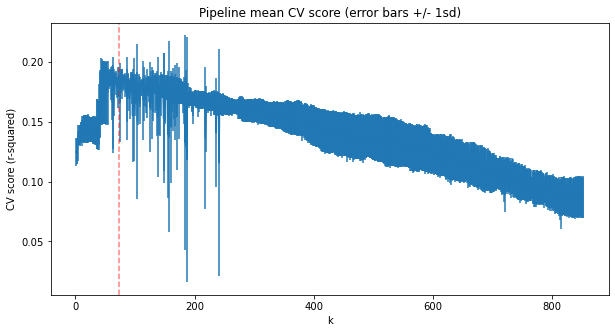

time: 116 ms (started: 2021-08-16 00:43:15 -07:00)


In [55]:
#Code task 20#
#Assign the value of k from the above dict of `best_params_` and assign it to `best_k`
best_k = lr_grid_cv.best_params_['selectkbest__k']
plt.subplots(figsize=(10, 5))
plt.errorbar(cv_k, score_mean, yerr=score_std)
plt.axvline(x=best_k, c='r', ls='--', alpha=.5)
plt.xlabel('k')
plt.ylabel('CV score (r-squared)')
plt.title('Pipeline mean CV score (error bars +/- 1sd)');

The above suggests a good value for k is 8. There was an initial rapid increase with k, followed by a slow decline. Also noticeable is the variance of the results greatly increase above k=8. As you increasingly overfit, expect greater swings in performance as different points move in and out of the train/test folds.

Which features were most useful? Step into your best model, shown below. Starting with the fitted grid search object, you get the best estimator, then the named step 'selectkbest', for which you can its `get_support()` method for a logical mask of the features selected.

In [56]:
selected = lr_grid_cv.best_estimator_.named_steps.selectkbest.get_support()
selected

array([ True,  True,  True,  True,  True,  True,  True, False, False,
       False,  True, False,  True, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False,  True, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

time: 2.43 ms (started: 2021-08-16 00:43:15 -07:00)


Similarly, instead of using the 'selectkbest' named step, you can access the named step for the linear regression model and, from that, grab the model coefficients via its `coef_` attribute:

In [57]:
#Code task 21#
#Get the linear model coefficients from the `coef_` attribute and store in `coefs`,
#get the matching feature names from the column names of the dataframe,
#and display the results as a pandas Series with `coefs` as the values and `features` as the index,
#sorting the values in descending order
coefs = lr_grid_cv.best_estimator_.named_steps.linearregression.coef_
features = X_train.columns[selected]
pd.Series(coefs, index=features).sort_values(ascending=False)

wins_diff              1.708295e+13
opp_wins_diff          1.708295e+13
win_pct_diff           6.365408e+12
opp_win_pct_diff       6.365408e+12
w_pct_cmax12_diff_x    2.612892e+12
                           ...     
w_pct_cma5_diff_y     -1.676340e+12
w_pct_cma999_diff_y   -1.977505e+12
w_pct_cmax12_diff_y   -2.612892e+12
losses_diff           -3.454143e+13
opp_losses_diff       -3.454143e+13
Length: 74, dtype: float64

time: 3.03 ms (started: 2021-08-16 00:43:15 -07:00)


These results suggest that vertical drop is your biggest positive feature. This makes intuitive sense and is consistent with what you saw during the EDA work. Also, you see the area covered by snow making equipment is a strong positive as well. People like guaranteed skiing! The skiable terrain area is negatively associated with ticket price! This seems odd. People will pay less for larger resorts? There could be all manner of reasons for this. It could be  an effect whereby larger resorts can host more visitors at any one time and so can charge less per ticket. As has been mentioned previously, the data are missing information about visitor numbers. Bear in mind,  the coefficient for skiable terrain is negative _for this model_. For example, if you kept the total number of chairs and fastQuads constant, but increased the skiable terrain extent, you might imagine the resort is worse off because the chairlift capacity is stretched thinner.

<font color='red'>"As has been mentioned previously, the data are missing information about visitor numbers"!!!<font>

## 4.10 Random Forest Model<a id='4.10_Random_Forest_Model'></a>

A model that can work very well in a lot of cases is the random forest. For regression, this is provided by `sklearn`'s `RandomForestRegressor` class.

Time to stop the bad practice of repeatedly checking performance on the test split. Instead, go straight from defining the pipeline to assessing performance using cross-validation. `cross_validate` will perform the fitting as part of the process. This uses the default settings for the random forest so you'll then proceed to investigate some different hyperparameters.

### 4.10.1 Define the pipeline<a id='4.10.1_Define_the_pipeline'></a>

In [58]:
#Code task 22#
#Define a pipeline comprising the steps:
#SimpleImputer() with a strategy of 'median'
#StandardScaler(),
#and then RandomForestRegressor() with a random state of 47
RF_pipe = make_pipeline(
    #SimpleImputer(strategy='median'),
    #StandardScaler(),
    RandomForestRegressor(random_state=47)
)

time: 386 µs (started: 2021-08-16 00:43:15 -07:00)


### 4.10.2 Fit and assess performance using cross-validation<a id='4.10.2_Fit_and_assess_performance_using_cross-validation'></a>

In [59]:
#Code task 23#
#Call `cross_validate` to estimate the pipeline's performance.
#Pass it the random forest pipe object, `X_train` and `y_train`,
#and get it to use 5-fold cross-validation
rf_default_cv_results = cross_validate(RF_pipe, X_train, y_train, cv=5)

time: 17min 32s (started: 2021-08-16 00:43:15 -07:00)


In [60]:
rf_cv_scores = rf_default_cv_results['test_score']
rf_cv_scores

array([0.17178679, 0.18483279, 0.17073453, 0.18220283, 0.16305472])

time: 1.08 ms (started: 2021-08-16 01:00:48 -07:00)


In [61]:
np.mean(rf_cv_scores), np.std(rf_cv_scores)

(0.1745223295411953, 0.007982885519787146)

time: 858 µs (started: 2021-08-16 01:00:48 -07:00)


### 4.10.3 Hyperparameter search using GridSearchCV<a id='4.10.3_Hyperparameter_search_using_GridSearchCV'></a>

Random forest has a number of hyperparameters that can be explored, however here you'll limit yourselves to exploring some different values for the number of trees. You'll try it with and without feature scaling, and try both the mean and median as strategies for imputing missing values.

In [62]:
n_est = [int(n) for n in np.logspace(start=1, stop=3, num=20)]
n_est


[10,
 12,
 16,
 20,
 26,
 33,
 42,
 54,
 69,
 88,
 112,
 143,
 183,
 233,
 297,
 379,
 483,
 615,
 784,
 1000]

time: 1.17 ms (started: 2021-08-16 01:00:48 -07:00)


In [63]:
grid_params = {
        #SimpleImputer(strategy='median'),
    #StandardScaler(),
        'randomforestregressor__n_estimators': [200],
        'randomforestregressor__max_depth': [5, 10, 20, 1000],
        'randomforestregressor__min_samples_split': [50, 100, 1000]
}
grid_params

{'randomforestregressor__n_estimators': [200],
 'randomforestregressor__max_depth': [5, 10, 20, 1000],
 'randomforestregressor__min_samples_split': [50, 100, 1000]}

time: 1.09 ms (started: 2021-08-16 01:00:48 -07:00)


In [64]:
#Code task 24#
#Call `GridSearchCV` with the random forest pipeline, passing in the above `grid_params`
#dict for parameters to evaluate, 5-fold cross-validation, and all available CPU cores (if desired)
rf_grid_cv = GridSearchCV(RF_pipe, param_grid=grid_params, cv=5, n_jobs=-1)

time: 287 µs (started: 2021-08-16 01:00:48 -07:00)


In [65]:
#Code task 25#
#Now call the `GridSearchCV`'s `fit()` method with `X_train` and `y_train` as arguments
#to actually start the grid search. This may take a minute or two.
rf_grid_cv.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('randomforestregressor',
                                        RandomForestRegressor(random_state=47))]),
             n_jobs=-1,
             param_grid={'randomforestregressor__max_depth': [5, 10, 20, 1000],
                         'randomforestregressor__min_samples_split': [50, 100,
                                                                      1000],
                         'randomforestregressor__n_estimators': [200]})

time: 43min 40s (started: 2021-08-16 01:00:48 -07:00)


In [66]:
#Code task 26#
#Print the best params (`best_params_` attribute) from the grid search
rf_grid_cv.best_params_

{'randomforestregressor__max_depth': 10,
 'randomforestregressor__min_samples_split': 100,
 'randomforestregressor__n_estimators': 200}

time: 898 µs (started: 2021-08-16 01:44:28 -07:00)


It looks like imputing with the median helps, but scaling the features doesn't.

In [67]:
rf_best_cv_results = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, cv=5)
rf_best_scores = rf_best_cv_results['test_score']
rf_best_scores

array([0.18079089, 0.20200578, 0.18352633, 0.19305312, 0.17456952])

time: 21min 7s (started: 2021-08-16 01:44:28 -07:00)


In [68]:
np.mean(rf_best_scores), np.std(rf_best_scores)

(0.18678912840354067, 0.009661548146707312)

time: 1.47 ms (started: 2021-08-16 02:05:36 -07:00)


You've marginally improved upon the default CV results. Random forest has many more hyperparameters you could tune, but we won't dive into that here.

<font color='red'>what hyperparameters did we just tune???????? n_est????????<font>

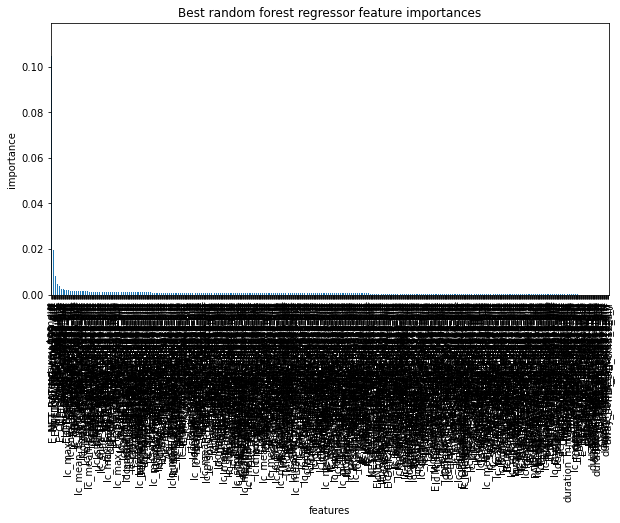

time: 8.12 s (started: 2021-08-16 02:05:36 -07:00)


In [69]:
#Code task 27#
#Plot a barplot of the random forest's feature importances,
#assigning the `feature_importances_` attribute of 
#`rf_grid_cv.best_estimator_.named_steps.randomforestregressor` to the name `imps` to then
#create a pandas Series object of the feature importances, with the index given by the
#training data column names, sorting the values in descending order
plt.subplots(figsize=(10, 5))
imps = rf_grid_cv.best_estimator_.named_steps.randomforestregressor.feature_importances_
rf_feat_imps = pd.Series(imps, index=X_train.columns).sort_values(ascending=False)
rf_feat_imps.plot(kind='bar')
plt.xlabel('features')
plt.ylabel('importance')
plt.title('Best random forest regressor feature importances');

In [70]:
rf_feat_imps

away_home_a                     0.113563
spread_cma999_diff              0.104860
NET_RATING_cma999_diff          0.085476
E_NET_RATING_cma999_diff        0.080330
PIE_cma999_diff                 0.019765
                                  ...   
USG_PCT_cmax12_diff             0.000000
duration_minutes_cmax12_diff    0.000000
min_cmax12_diff                 0.000000
away_home__cmax12_diff_y        0.000000
min_sm_cma12_diff               0.000000
Length: 852, dtype: float64

time: 2.16 ms (started: 2021-08-16 02:05:44 -07:00)


In [71]:
rf_feat_imps[0:30]

away_home_a                       0.113563
spread_cma999_diff                0.104860
NET_RATING_cma999_diff            0.085476
E_NET_RATING_cma999_diff          0.080330
PIE_cma999_diff                   0.019765
strength_of_schedule_diff         0.015255
opp_losses_diff                   0.010931
E_NET_RATING_cma12_diff           0.008064
losses_diff                       0.005260
PIE_cma12_diff                    0.004878
w_pct_cma5_diff_y                 0.004793
w_pct_cma5_diff_x                 0.004722
spread_cma12_diff                 0.004417
wins_diff                         0.003663
w_pct_cmax5_diff_y                0.002975
E_OFF_RATING_cma999_diff          0.002521
NET_RATING_cma12_diff             0.002516
EFG_PCT_cma999_diff               0.002499
pf_cma999_diff                    0.002449
opp_opps_losses_diff              0.002444
TS_PCT_cma999_diff                0.002354
w_pct_cmax5_diff_x                0.002269
pf_cmax5_diff                     0.002207
lc_mean_PIE

time: 1.98 ms (started: 2021-08-16 02:05:44 -07:00)


In [1]:
#feature importance affected by collinearity. 'scores are halved if they are identical'?????

#https://www.quora.com/Does-the-random-forests-technique-suffer-if-there-is-a-multi-colinerarity-present-in-the-features-data-when-trying-to-predict-the-classification-of-the-next-datapoint-If-not-why


In [2]:
# can reduce runtime by dropping the bottom 5% of feature importances

#https://towardsdatascience.com/improving-random-forest-in-python-part-1-893916666cd



In [ ]:
#play with max depth

#specify maximum number of features to include in each node split


#https://www.keboola.com/blog/random-forest-regression

Encouragingly, the dominant top four features are in common with your linear model:
* w_pct_cma_diff
* away_home_a
* spread_cma_diff
* E_NET_RATING_cma_diff


## 4.11 Final Model Selection<a id='4.11_Final_Model_Selection'></a>

Time to select your final model to use for further business modeling! It would be good to revisit the above model selection; there is undoubtedly more that could be done to explore possible hyperparameters.
It would also be worthwhile to investigate removing the least useful features. Gathering or calculating, and storing, features adds business cost and dependencies, so if features genuinely are not needed they should be removed.
Building a simpler model with fewer features can also have the advantage of being easier to sell (and/or explain) to stakeholders.
Certainly there seem to be four strong features here and so a model using only those would probably work well.
However, you want to explore some different scenarios where other features vary so keep the fuller 
model for now. 
The business is waiting for this model and you have something that you have confidence in to be much better than guessing with the average price.

Or, rather, you have two "somethings". You built a best linear model and a best random forest model. You need to finally choose between them. You can calculate the mean absolute error using cross-validation. Although `cross-validate` defaults to the $R^2$ [metric for scoring](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring) regression, you can specify the mean absolute error as an alternative via
the `scoring` parameter.

### 4.11.1 Linear regression model performance<a id='4.11.1_Linear_regression_model_performance'></a>

In [72]:
# 'neg_mean_absolute_error' uses the (negative of) the mean absolute error
lr_neg_mae = cross_validate(lr_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

time: 1.66 s (started: 2021-08-16 02:05:44 -07:00)


In [73]:
lr_mae_mean = np.mean(-1 * lr_neg_mae['test_score'])
lr_mae_std = np.std(-1 * lr_neg_mae['test_score'])
lr_mae_mean, lr_mae_std

(9.68361170162784, 0.2100935973491271)

time: 2.12 ms (started: 2021-08-16 02:05:46 -07:00)


In [74]:
mean_absolute_error(y_test, lr_grid_cv.best_estimator_.predict(X_test))

9.635308541548875

time: 17.2 ms (started: 2021-08-16 02:05:46 -07:00)


### 4.11.2 Random forest regression model performance<a id='4.11.2_Random_forest_regression_model_performance'></a>

In [75]:
rf_neg_mae = cross_validate(rf_grid_cv.best_estimator_, X_train, y_train, 
                            scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)

time: 5min 9s (started: 2021-08-16 02:05:46 -07:00)


In [76]:
rf_mae_mean = np.mean(-1 * rf_neg_mae['test_score'])
rf_mae_std = np.std(-1 * rf_neg_mae['test_score'])
rf_mae_mean, rf_mae_std

(9.695380250518955, 0.2197512303781018)

time: 1.44 ms (started: 2021-08-16 02:10:56 -07:00)


In [77]:
mean_absolute_error(y_test, rf_grid_cv.best_estimator_.predict(X_test))

9.584087943931355

time: 57.7 ms (started: 2021-08-16 02:10:56 -07:00)


### 4.11.3 Conclusion<a id='4.11.3_Conclusion'></a>

The random forest model has a lower cross-validation mean absolute error by almost \\$1. It also exhibits less variability. Verifying performance on the test set produces performance consistent with the cross-validation results.

## 4.12 Data quantity assessment<a id='4.12_Data_quantity_assessment'></a>

Finally, you need to advise the business whether it needs to undertake further data collection. Would more data be useful? We're often led to believe more data is always good, but gathering data invariably has a cost associated with it. Assess this trade off by seeing how performance varies with differing data set sizes. The `learning_curve` function does this conveniently.

In [78]:
fractions = [.2, .25, .3, .35, .4, .45, .5, .6, .75, .8, 1.0]
train_size, train_scores, test_scores = learning_curve(pipe, X_train, y_train, train_sizes=fractions)
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value e

time: 1.54 s (started: 2021-08-16 02:10:56 -07:00)


/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms
/opt/anaconda3/lib/python3.8/site-packages/sklearn/feature_selection/_univariate_selection.py:302: RuntimeWarning: invalid value encountered in true_divide
  corr /= X_norms


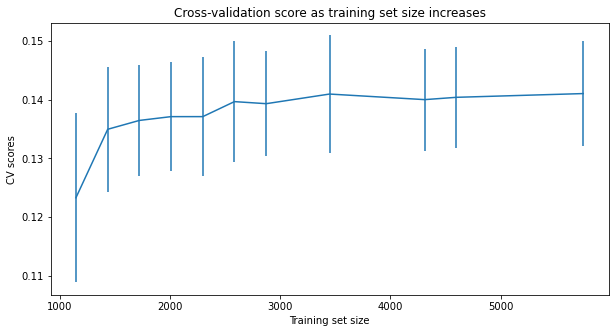

time: 78.5 ms (started: 2021-08-16 02:10:57 -07:00)


In [79]:
plt.subplots(figsize=(10, 5))
plt.errorbar(train_size, test_scores_mean, yerr=test_scores_std)
plt.xlabel('Training set size')
plt.ylabel('CV scores')
plt.title('Cross-validation score as training set size increases');

This shows that you seem to have plenty of data. There's an initial rapid improvement in model scores as one would expect, but it's essentially levelled off by around a sample size of 40-50.

## 4.13 Save best model object from pipeline<a id='4.13_Save_best_model_object_from_pipeline'></a>

In [80]:
#Code task 28#
#This may not be "production grade ML deployment" practice, but adding some basic
#information to your saved models can save your bacon in development.
#Just what version model have you just loaded to reuse? What version of `sklearn`
#created it? When did you make it?
#Assign the pandas version number (`pd.__version__`) to the `pandas_version` attribute,
#the numpy version (`np.__version__`) to the `numpy_version` attribute,
#the sklearn version (`sklearn_version`) to the `sklearn_version` attribute,
#and the current datetime (`datetime.datetime.now()`) to the `build_datetime` attribute
#Let's call this model version '1.0'
best_model = rf_grid_cv.best_estimator_
best_model.version = '1.0'
best_model.pandas_version = pd.__version__
best_model.numpy_version = np.__version__
best_model.sklearn_version = sklearn_version
best_model.X_columns = [col for col in X_train.columns]
best_model.build_datetime = datetime.datetime.now()
    
modelpath = os.path.join('..', 'models')
if not os.path.exists(modelpath):
    os.mkdir(modelpath)
nbamodel_path = os.path.join(modelpath, 'nba_spread_a_model_161.pkl')
if not os.path.exists(nbamodel_path):
    with open(nbamodel_path, 'wb') as f:
        pickle.dump(best_model, f)

time: 8.2 ms (started: 2021-08-16 02:10:58 -07:00)


## 4.14 Summary<a id='4.14_Summary'></a>

**Q: 1** Write a summary of the work in this notebook. Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did. Then highlight that you built a linear model and the features that found. Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate. Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. State which model you have decided to use going forwards and why. This summary should provide a quick overview for someone wanting to know quickly why the given model was chosen for the next part of the business problem to help guide important business decisions.

Capture the fact that you gained a baseline idea of performance by simply taking the average price and how well that did.
-Average price yielded an R^2, explained variance, of 0 and a mean absolute error of 18 and 19 on the training (i.e. y_train) and testing (i.e. y_train) sets respectively when compared to their predicted average 'AdultWeekend' ticket price (i.e. y_tr_pred).

Then highlight that you built a linear model and the features that found.
-In building a linear model, features found (using GridSearchCV) included vertical_drop, Snow Making_ac, total_chairs, fastQuads, Runs, LongestRun_mi, trams, SkiableTerrain_ac. In selecting eight (8) features (i.e. hyperparameter k=8) in linear regression to predict 'AdultWeekend' ticket price (i.e. y_train and y_test), the cross validation average test score of R^2 (i.e. explained variance) performance reached a maximum.


Comment on the estimate of its performance from cross-validation and whether its performance on the test split was consistent with this estimate.
-Cross-validation (with number of folds k=5) performance using linear regression model with 15 features (i.e. pipe15) showed an average R^2 score of .6349 and average std of .095. Using the pipe15 model, mean explained variance R^2 of cross-validation is close to the test split R^2 score .6347.


Also highlight that a random forest regressor was tried, what preprocessing steps were found to be best, and again what its estimated performance via cross-validation was and whether its performance on the test set was consistent with that. 
-Preprocessing steps that were found to be best included ?using n_est=69,? omitting the use of feature scaling, and using median instead of mean for feature imputing.
-The estimated performance of random forest regressor via cross-validation was a mean absolute error of 9.754 and standard deviation of 1.353.
-This performance was consistent with performance of the test set where mean absolute error was 9.342 using y_test and X_test.

State which model you have decided to use going forwards and why.
We have decided to go forwards with the random forest regression model because it yields the lower MAE (mean absolute error) between linear regression at 10.448 and random forest regression at 9.754, each by cross validation.